# Agents

Agents are typically implemented as an LLM performing actions using tools. They operate in continuous feedback loops, and are used in situations where problems and solutions are unpredictable. Agents have more autonomy than workflows, and can make decisions about the tools they use and how to solve problems. You can still define the available toolset and guidelines for how agents behave

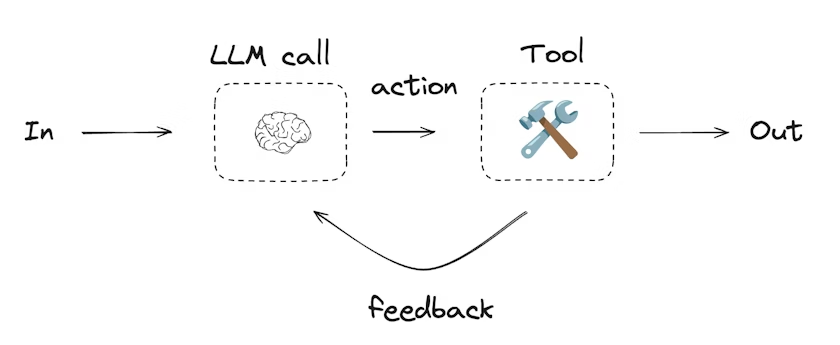

In [8]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")

from langchain.chat_models import init_chat_model

llm = init_chat_model("claude-haiku-4-5", temperature=0, max_tokens=100)

In [9]:
from langchain.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

## By using the Graph API

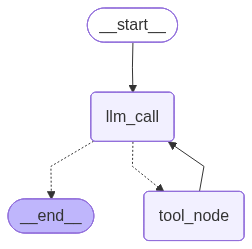

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================

[{'id': 'toolu_01R4VH2Pma2qe6MUQwZ35QcK', 'caller': {'type': 'direct'}, 'input': {'a': 3, 'b': 4}, 'name': 'add', 'type': 'tool_use'}]
Tool Calls:
  add (toolu_01R4VH2Pma2qe6MUQwZ35QcK)
 Call ID: toolu_01R4VH2Pma2qe6MUQwZ35QcK
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.


In [10]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage
from typing_extensions import Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

## By using the Functional API

In [11]:
from langgraph.graph import add_messages
from langchain.messages import (
    SystemMessage,
    HumanMessage,
    ToolCall,
)
from langchain_core.messages import BaseMessage
from langgraph.func import entrypoint, task


@task
def call_llm(messages: list[BaseMessage]):
    """LLM decides whether to call a tool or not"""
    return llm_with_tools.invoke(
        [
            SystemMessage(
                content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
            )
        ]
        + messages
    )


@task
def call_tool(tool_call: ToolCall):
    """Performs the tool call"""
    tool = tools_by_name[tool_call["name"]]
    return tool.invoke(tool_call)


@entrypoint()
def agent(messages: list[BaseMessage]):
    llm_response = call_llm(messages).result()

    while True:
        if not llm_response.tool_calls:
            break

        # Execute tools
        tool_result_futures = [
            call_tool(tool_call) for tool_call in llm_response.tool_calls
        ]
        tool_results = [fut.result() for fut in tool_result_futures]
        messages = add_messages(messages, [llm_response, *tool_results])
        llm_response = call_llm(messages).result()

    messages = add_messages(messages, llm_response)
    return messages


# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
for chunk in agent.stream(messages, stream_mode="updates"):
    print(chunk)
    print("\n")

{'call_llm': AIMessage(content=[{'id': 'toolu_012tqJT2Acrpta8W5zz8QwXt', 'caller': {'type': 'direct'}, 'input': {'a': 3, 'b': 4}, 'name': 'add', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01HNDorGjkX5ujou8JNxFwDR', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 792, 'output_tokens': 69, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019cf155-641a-76e3-9a6d-5f4bb63bdb5c-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'toolu_012tqJT2Acrpta8W5zz8QwXt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 792, 'output_tokens': 69, 'total_tokens': 861, 'input_token